Training dynamics models...
Epoch 0: Fwd Loss=0.013449, Bwd Loss=0.009853
Epoch 10: Fwd Loss=0.000001, Bwd Loss=0.000003


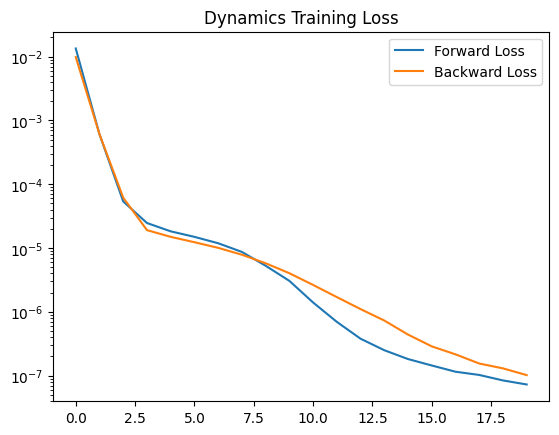

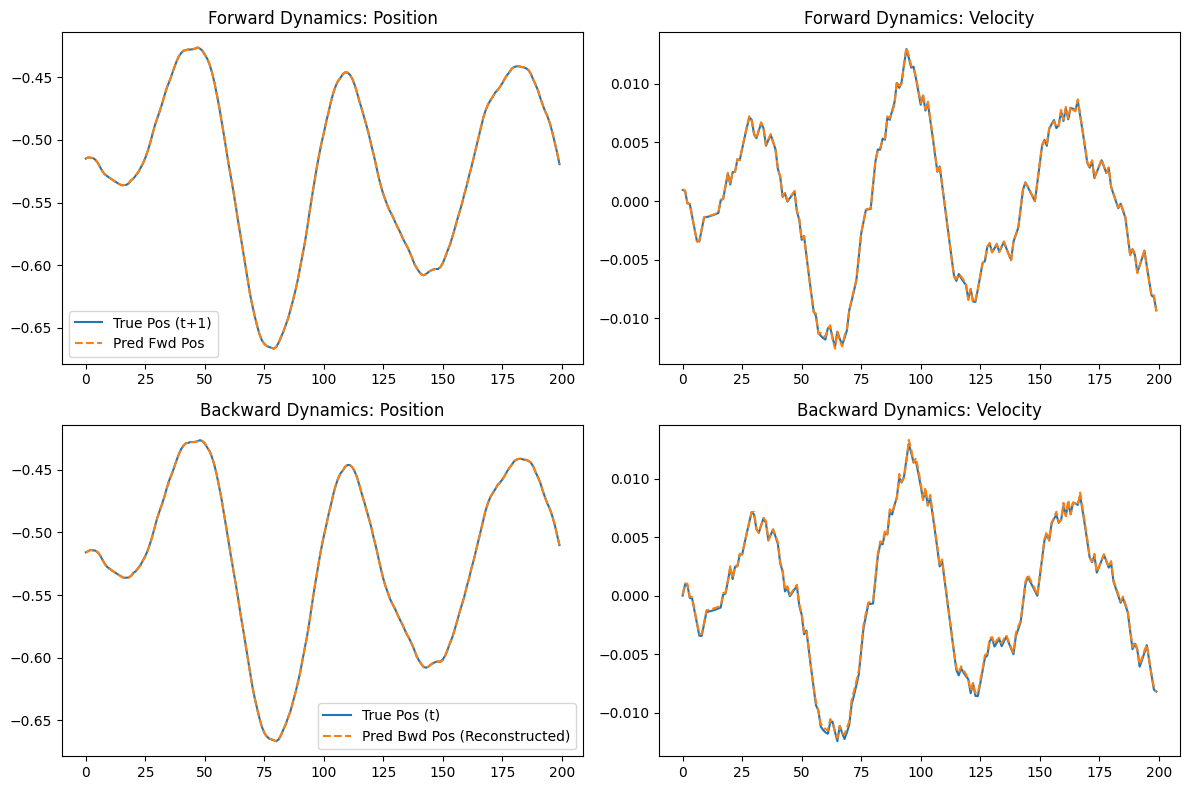

Verification complete. Check 'dynamics_check_mountaincar.png'.


In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Configuration ===
ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 64
LR = 1e-3
BATCH_SIZE = 64
EPOCHS = 20
DATA_STEPS = 10000

# === 1. Define the Models ===

class DynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Input: State + Action (we embed action or concat one-hot)
        # Simple concat: State inputs + Action index (1 dim)
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, state_dim) # Output: Predicted State
        )

    def forward(self, state, action):
        # State: [Batch, StateDim]
        # Action: [Batch, 1]
        x = torch.cat([state, action], dim=1)
        return self.net(x)

# === 2. Data Collection ===

def collect_data(env, steps):
    states = []
    actions = []
    next_states = []
    
    s, _ = env.reset()
    for _ in range(steps):
        a = env.action_space.sample()
        ns, r, term, trunc, _ = env.step(a)
        
        states.append(s)
        actions.append([a]) # Keep as list for tensor conversion
        next_states.append(ns)
        
        if term or trunc:
            s, _ = env.reset()
        else:
            s = ns
            
    return (np.array(states, dtype=np.float32), 
            np.array(actions, dtype=np.float32), 
            np.array(next_states, dtype=np.float32))

# === 3. Training Loop ===

def train_models():
    env = gym.make(ENV_NAME)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # Discrete(3)
    
    print(f"Collecting {DATA_STEPS} transitions from {ENV_NAME}...")
    S, A, NS = collect_data(env, DATA_STEPS)
    
    # Convert to Tensors
    t_S = torch.tensor(S)
    t_A = torch.tensor(A)
    t_NS = torch.tensor(NS)
    
    dataset = torch.utils.data.TensorDataset(t_S, t_A, t_NS)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize Models
    # Forward: (s, a) -> s'
    fwd_model = DynamicsModel(state_dim, action_dim)
    # Backward: (s', a) -> s  (Predict PREV state given CURRENT state and PREV action)
    bwd_model = DynamicsModel(state_dim, action_dim)
    
    opt_f = optim.Adam(fwd_model.parameters(), lr=LR)
    opt_b = optim.Adam(bwd_model.parameters(), lr=LR)
    
    loss_fn = nn.MSELoss()
    
    print("Training dynamics models...")
    loss_history = {'fwd': [], 'bwd': []}
    
    for epoch in range(EPOCHS):
        total_f_loss = 0
        total_b_loss = 0
        
        for s_batch, a_batch, ns_batch in loader:
            # --- Train Forward ---
            pred_ns = fwd_model(s_batch, a_batch)
            loss_f = loss_fn(pred_ns, ns_batch)
            
            opt_f.zero_grad()
            loss_f.backward()
            opt_f.step()
            total_f_loss += loss_f.item()
            
            # --- Train Backward ---
            # Input: Next State (current) + Action (that led here)
            # Target: State (previous)
            pred_s = bwd_model(ns_batch, a_batch)
            loss_b = loss_fn(pred_s, s_batch)
            
            opt_b.zero_grad()
            loss_b.backward()
            opt_b.step()
            total_b_loss += loss_b.item()
            
        avg_f = total_f_loss / len(loader)
        avg_b = total_b_loss / len(loader)
        loss_history['fwd'].append(avg_f)
        loss_history['bwd'].append(avg_b)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Fwd Loss={avg_f:.6f}, Bwd Loss={avg_b:.6f}")
            
    return fwd_model, bwd_model, loss_history

# === 4. Visualization & Verification ===

def verify_models(env, fwd, bwd):
    """
    Runs a fresh trajectory and plots the True vs Predicted path
    for both forward (future) and backward (reconstruction) directions.
    """
    S, A, NS = collect_data(env, 200) # Short trajectory for plotting
    
    t_S = torch.tensor(S)
    t_A = torch.tensor(A)
    t_NS = torch.tensor(NS)
    
    with torch.no_grad():
        pred_NS = fwd(t_S, t_A).numpy()
        pred_S = bwd(t_NS, t_A).numpy()
        
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Forward Checks
    axes[0,0].plot(NS[:, 0], label='True Pos (t+1)')
    axes[0,0].plot(pred_NS[:, 0], '--', label='Pred Fwd Pos')
    axes[0,0].set_title("Forward Dynamics: Position")
    axes[0,0].legend()
    
    axes[0,1].plot(NS[:, 1], label='True Vel (t+1)')
    axes[0,1].plot(pred_NS[:, 1], '--', label='Pred Fwd Vel')
    axes[0,1].set_title("Forward Dynamics: Velocity")
    
    # Backward Checks
    axes[1,0].plot(S[:, 0], label='True Pos (t)')
    axes[1,0].plot(pred_S[:, 0], '--', label='Pred Bwd Pos (Reconstructed)')
    axes[1,0].set_title("Backward Dynamics: Position")
    axes[1,0].legend()
    
    axes[1,1].plot(S[:, 1], label='True Vel (t)')
    axes[1,1].plot(pred_S[:, 1], '--', label='Pred Bwd Vel (Reconstructed)')
    axes[1,1].set_title("Backward Dynamics: Velocity")
    
    plt.tight_layout()
    plt.savefig('dynamics_check_mountaincar.png')
    plt.show()

# === Main ===
if __name__ == "__main__":
    f_model, b_model, history = train_models()
    
    # Plot training curve
    plt.figure()
    plt.plot(history['fwd'], label='Forward Loss')
    plt.plot(history['bwd'], label='Backward Loss')
    plt.yscale('log')
    plt.legend()
    plt.title("Dynamics Training Loss")
    plt.show()
    
    # Verify visual fit
    env = gym.make(ENV_NAME)
    verify_models(env, f_model, b_model)
    print("Verification complete. Check 'dynamics_check_mountaincar.png'.")

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Configuration ===
ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 64
DYN_LR = 0.002
U_LR = 0.0005
BATCH_SIZE = 128
DYN_EPOCHS = 20
U_EPOCHS = 1000
DATA_STEPS = 20000
BETA = 1.0

# === 1. Residual Dynamics Models ===
class ResidualDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, HIDDEN_DIM),
            nn.Tanh(), # Tanh often smoother for physics
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, state_dim) 
        )

    def forward(self, state, action):
        # Action is a scalar index (0, 1, 2)
        x = torch.cat([state, action], dim=1)
        return self.net(x)

def train_dynamics(env):
    print(f"--- 1. Collecting {DATA_STEPS} transitions for Dynamics ---")
    states, actions, next_states = [], [], []
    s, _ = env.reset()
    for _ in range(DATA_STEPS):
        a = env.action_space.sample() # Random policy is fine for coverage
        ns, r, term, trunc, _ = env.step(a)
        
        states.append(s); actions.append([float(a)]); next_states.append(ns)
        if term or trunc: s, _ = env.reset()
        else: s = ns
            
    S = np.array(states, dtype=np.float32)
    A = np.array(actions, dtype=np.float32)
    NS = np.array(next_states, dtype=np.float32)
    
    # --- Normalization Statistics ---
    s_mean, s_std = S.mean(axis=0), S.std(axis=0) + 1e-6
    d_fwd = NS - S; d_mean, d_std = d_fwd.mean(axis=0), d_fwd.std(axis=0) + 1e-6
    d_bwd = S - NS; db_mean, db_std = d_bwd.mean(axis=0), d_bwd.std(axis=0) + 1e-6
    
    stats = {'s_mean': torch.tensor(s_mean), 's_std': torch.tensor(s_std),
             'd_mean': torch.tensor(d_mean), 'd_std': torch.tensor(d_std),
             'db_mean': torch.tensor(db_mean), 'db_std': torch.tensor(db_std)}

    # Prepare Tensors
    t_S = torch.tensor((S - s_mean) / s_std)
    t_A = torch.tensor(A)
    t_Tgt_F = torch.tensor((d_fwd - d_mean) / d_std)
    t_Tgt_B = torch.tensor((d_bwd - db_mean) / db_std)
    # We also need t_NS normalized for backward input
    t_NS = torch.tensor((NS - s_mean) / s_std)
    
    dataset = torch.utils.data.TensorDataset(t_S, t_A, t_NS, t_Tgt_F, t_Tgt_B)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    fwd = ResidualDynamicsModel(2, 1)
    bwd = ResidualDynamicsModel(2, 1)
    opt_f = optim.Adam(fwd.parameters(), lr=DYN_LR)
    opt_b = optim.Adam(bwd.parameters(), lr=DYN_LR)
    loss_fn = nn.MSELoss()
    
    print("--- 2. Training Models ---")
    for ep in range(DYN_EPOCHS):
        lf_sum, lb_sum = 0, 0
        for s, a, ns, df, db in loader:
            # Train Forward
            loss_f = loss_fn(fwd(s, a), df)
            opt_f.zero_grad(); loss_f.backward(); opt_f.step()
            
            # Train Backward (Input is Next State)
            loss_b = loss_fn(bwd(ns, a), db)
            opt_b.zero_grad(); loss_b.backward(); opt_b.step()
            
            lf_sum += loss_f.item(); lb_sum += loss_b.item()
            
        if ep % 10 == 0:
            print(f"Ep {ep}: Fwd={lf_sum/len(loader):.4f}, Bwd={lb_sum/len(loader):.4f}")
            
    return fwd, bwd, stats

In [ ]:
# === 2. The U-Function Network ===
class UNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Outputs Log-U (Q-values) for each action
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, action_dim) 
        )

    def forward(self, state):
        return self.net(state)

# === 3. The Model-Based Flow Trainer ===
class EVE_Trainer:
    def __init__(self, fwd, bwd, stats, state_dim=2, action_dim=3):
        self.fwd = fwd
        self.bwd = bwd
        self.stats = stats
        self.u_net = UNet(state_dim, action_dim)
        self.target_net = UNet(state_dim, action_dim) # For stability
        self.target_net.load_state_dict(self.u_net.state_dict())
        
        self.optimizer = optim.Adam(self.u_net.parameters(), lr=U_LR)
        self.beta = BETA
        self.n_actions = action_dim

    def predict_next_state(self, s_norm, action_idx):
        """ Use Forward Model to get s' (normalized) """
        # Create action tensor [Batch, 1]
        a = torch.full((s_norm.shape[0], 1), float(action_idx))
        with torch.no_grad():
            delta_norm = self.fwd(s_norm, a)
            # De-normalize delta, add to S, re-normalize
            # Simplification: Assume linear scaling holds roughly locally
            # s' ~ s + delta_model
            # Proper way: unscale -> add -> rescale.
            s_unscaled = s_norm * self.stats['s_std'] + self.stats['s_mean']
            delta_unscaled = delta_norm * self.stats['d_std'] + self.stats['d_mean']
            ns_unscaled = s_unscaled + delta_unscaled
            ns_norm = (ns_unscaled - self.stats['s_mean']) / self.stats['s_std']
        return ns_norm

    def predict_prev_state(self, s_norm, action_idx):
        """ Use Backward Model to get s_prev (normalized) """
        a = torch.full((s_norm.shape[0], 1), float(action_idx))
        with torch.no_grad():
            delta_norm = self.bwd(s_norm, a)
            s_unscaled = s_norm * self.stats['s_std'] + self.stats['s_mean']
            delta_unscaled = delta_norm * self.stats['db_std'] + self.stats['db_mean']
            # Remember backward delta was defined as S - NS. So S = NS + Delta
            prev_unscaled = s_unscaled + delta_unscaled
            prev_norm = (prev_unscaled - self.stats['s_mean']) / self.stats['s_std']
        return prev_norm

    def train_u_step(self, s_batch):
        """
        Updates U-Net using the Fixed Point Equation on the batch of states.
        s_batch is Normalized.
        """
        # 1. Forward Term: E[ u(s', :) ]
        # We sum over all possible next actions a' (Uniform Prior)
        log_num_terms = []
        for a_prime in range(self.n_actions):
            # Predict s' for current action 'a' (wait, the formula loops over s' actions)
            # Actually, update is for u(s,a). We need s' resulting from (s,a).
            # So we iterate over 'a' (the action we are updating u for).
            pass 
        
        # We update ALL actions for state s simultaneously.
        # Targets will be shape [Batch, Actions]
        
        log_u_targets = []
        
        for a_curr in range(self.n_actions):
            # --- A. Numerator Calculation ---
            # 1. Predict s' = Fwd(s, a_curr)
            sp_norm = self.predict_next_state(s_batch, a_curr)
            
            # 2. Evaluate u(s', :) using Target Net
            with torch.no_grad():
                q_next = self.target_net(sp_norm) # [Batch, 3]
            
            # 3. Log-Sum-Exp over next actions a' (Uniform Prior weight 1/N)
            # log( sum( exp(beta*Q) * 1/N ) )
            # = log(sum exp) - log(N)
            lse_next = torch.logsumexp(self.beta * q_next, dim=1) - np.log(self.n_actions)
            log_numerator = (1.0 / self.beta) * lse_next
            
            # --- B. Denominator Calculation ---
            # Sum over incoming edges.
            # We assume we could have arrived from ANY previous action a_prev
            # s_prev = Bwd(s, a_prev)
            
            denom_terms = []
            for a_prev in range(self.n_actions):
                # 1. Hallucinate predecessor s_bar
                sb_norm = self.predict_prev_state(s_batch, a_prev)
                
                # 2. Evaluate u(s_bar, a_prev)
                with torch.no_grad():
                    q_prev_all = self.target_net(sb_norm) # [Batch, 3]
                    q_prev = q_prev_all[:, a_prev]        # Only the action that led here
                
                # 3. Term is u^-1 = exp(-beta * Q)
                # Weighted by prior pi(a_prev | s_prev) = 1/N
                term = -self.beta * q_prev - np.log(self.n_actions)
                denom_terms.append(term.unsqueeze(1))
            
            # Log-Sum-Exp over the 3 possible predecessors
            denom_stack = torch.cat(denom_terms, dim=1) # [Batch, 3]
            lse_prev = torch.logsumexp(denom_stack, dim=1)
            
            # Term is u^-1. So log(Denom) = lse_prev.
            # We want to divide by Denom -> Subtract log(Denom)
            
            # --- C. Target Combination ---
            # u_new = ( Num / Denom ) ^ power
            # log(u) = power * (log_Num - log_Denom)
            
            power = self.beta / (1.0 + self.beta)
            target = power * (log_numerator - (1.0/self.beta) * lse_prev)
            
            log_u_targets.append(target.unsqueeze(1))
            
        # Combine targets [Batch, 3]
        targets = torch.cat(log_u_targets, dim=1)
        
        # --- D. Regression Update ---
        current_q = self.u_net(s_batch)
        
        # Gauge Fixing: Force mean Q to 0 to prevent drift
        current_q_centered = current_q - current_q.mean(dim=1, keepdim=True)
        targets_centered = targets - targets.mean(dim=1, keepdim=True)
        
        loss = nn.MSELoss()(current_q_centered, targets_centered)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def update_target(self):
        self.target_net.load_state_dict(self.u_net.state_dict())

In [ ]:

env = gym.make(ENV_NAME, render_mode=None)

# 1. Train Dynamics (Pre-training)
# fwd, bwd, stats = train_dynamics(env)

# 2. Initialize EVE Agent
agent = EVE_Trainer(fwd, bwd, stats)

print(f"--- 3. Learning U-Function (Beta={BETA}) ---")

# Use the collected states from dynamics training as our "State Distribution"
# Ideally, we would refresh this with a mixture policy, but static batch works for MountainCar
# Construct a loader just for states
S_raw = (stats['s_mean'] + stats['s_std'] * torch.randn(5000, 2)).numpy() # Dummy initialization

# Let's collect fresh states using random policy
S_new, _, _ = collect_data(env, 5000)
t_S = torch.tensor((S_new - stats['s_mean'].numpy()) / stats['s_std'].numpy())
loader = torch.utils.data.DataLoader(t_S, batch_size=128, shuffle=True)

losses = []

for epoch in range(U_EPOCHS):
    ep_loss = 0
    for s_batch in loader:
        loss = agent.train_u_step(s_batch)
        ep_loss += loss
        
    losses.append(ep_loss / len(loader))
    
    if epoch % 100 == 0:
        agent.update_target()
        print(f"Epoch {epoch}: U-Loss {np.log(losses[-1]):.6f}")

# --- 4. Visualization ---
print("Visualizing Learned Potential (U)...")

# Create a grid over Phase Space
# Position: -1.2 to 0.6
# Velocity: -0.07 to 0.07
pos = np.linspace(-1.2, 0.6, 50)
vel = np.linspace(-0.07, 0.07, 50)
mesh_pos, mesh_vel = np.meshgrid(pos, vel)

# Flatten and Normalize
states_grid = np.stack([mesh_pos.flatten(), mesh_vel.flatten()], axis=1)
s_mean = stats['s_mean'].numpy()
s_std = stats['s_std'].numpy()
t_grid = torch.tensor((states_grid - s_mean) / s_std).float()

with torch.no_grad():
    q_grid = agent.u_net(t_grid)
    # Calculate Value V(s) = log sum exp Q
    v_grid = torch.logsumexp(BETA * q_grid, dim=1).numpy()

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(mesh_pos, mesh_vel, v_grid.reshape(50, 50), levels=50, cmap='viridis')
plt.colorbar(label='Log Density (Energy)')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title(f'Learned Eigenvector Density (MountainCar)\nBeta={BETA}')
plt.savefig('mountaincar_eve_potential.png')
plt.show()

def collect_data(env, steps):
    # Quick helper for the main loop
    states, actions, next_states = [], [], []
    s, _ = env.reset()
    for _ in range(steps):
        a = env.action_space.sample()
        ns, r, term, trunc, _ = env.step(a)
        states.append(s); actions.append([float(a)]); next_states.append(ns)
        if term or trunc: s, _ = env.reset()
        else: s = ns
    return np.array(states, dtype=np.float32), np.array(actions, dtype=np.float32), np.array(next_states, dtype=np.float32)



--- 3. Learning U-Function (Beta=1.0) ---
Epoch 0: U-Loss -6.778874
Epoch 100: U-Loss -14.603595
Epoch 200: U-Loss -15.351175
Epoch 300: U-Loss -15.920450
Epoch 400: U-Loss -14.424518
Epoch 500: U-Loss -15.986836
Epoch 600: U-Loss -14.660246
Epoch 700: U-Loss -16.368416


KeyboardInterrupt: 

Visualizing Learned Potential (U)...


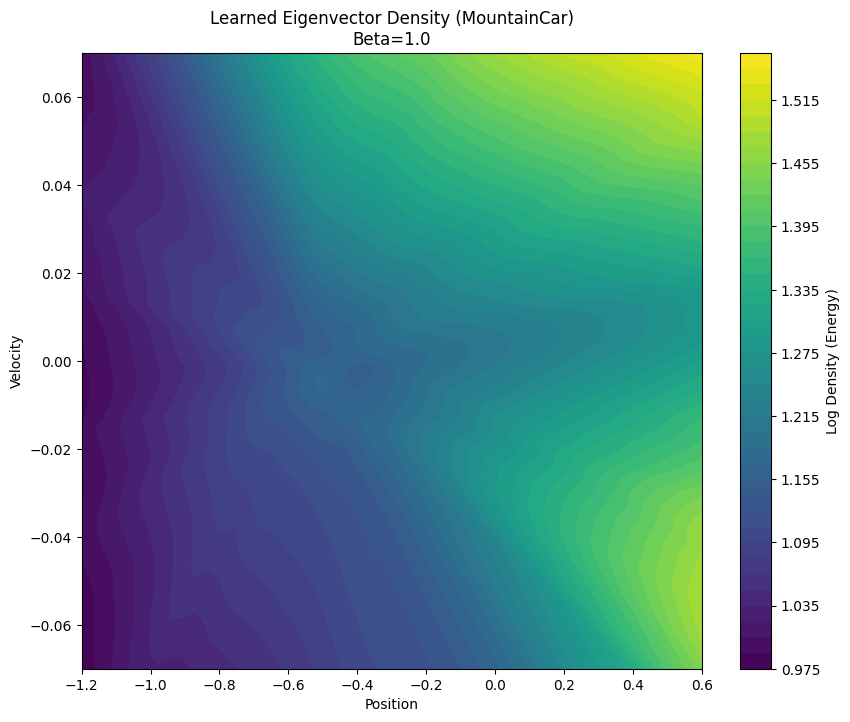

In [ ]:

# --- 4. Visualization ---
print("Visualizing Learned Potential (U)...")

# Create a grid over Phase Space
# Position: -1.2 to 0.6
# Velocity: -0.07 to 0.07
pos = np.linspace(-1.2, 0.6, 50)
vel = np.linspace(-0.07, 0.07, 50)
mesh_pos, mesh_vel = np.meshgrid(pos, vel)

# Flatten and Normalize
states_grid = np.stack([mesh_pos.flatten(), mesh_vel.flatten()], axis=1)
s_mean = stats['s_mean'].numpy()
s_std = stats['s_std'].numpy()
t_grid = torch.tensor((states_grid - s_mean) / s_std).float()

with torch.no_grad():
    q_grid = agent.u_net(t_grid)
    # Calculate Value V(s) = log sum exp Q
    v_grid = torch.logsumexp(BETA * q_grid, dim=1).numpy()

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(mesh_pos, mesh_vel, v_grid.reshape(50, 50), levels=50, cmap='viridis')
plt.colorbar(label='Log Density (Energy)')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title(f'Learned Eigenvector Density (MountainCar)\nBeta={BETA}')
plt.savefig('mountaincar_eve_potential.png')
plt.show()

def collect_data(env, steps):
    # Quick helper for the main loop
    states, actions, next_states = [], [], []
    s, _ = env.reset()
    for _ in range(steps):
        a = env.action_space.sample()
        ns, r, term, trunc, _ = env.step(a)
        states.append(s); actions.append([float(a)]); next_states.append(ns)
        if term or trunc: s, _ = env.reset()
        else: s = ns
    return np.array(states, dtype=np.float32), np.array(actions, dtype=np.float32), np.array(next_states, dtype=np.float32)

Running 50 evaluation episodes...
Running Random Baseline...

--- Results (N_BINS=20) ---
EVE Agent | Coverage: 58.25% | Norm Entropy: 0.7140
Random    | Coverage: 52.25% | Norm Entropy: 0.7104


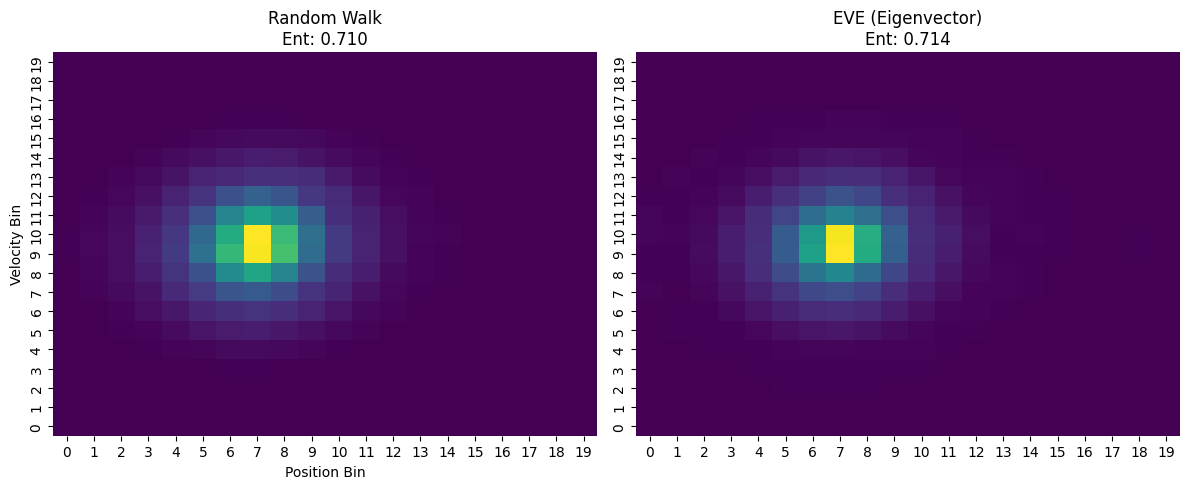

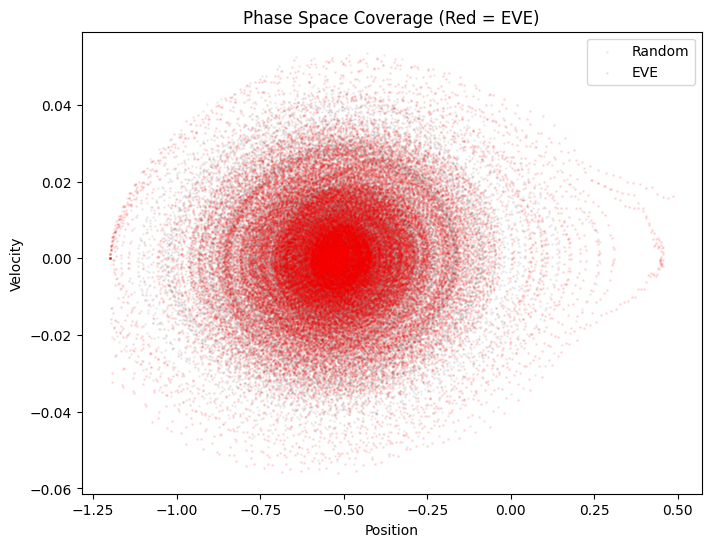

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 64
BETA = 1.0
N_BINS = 20  # Discretize space into 20x20 grid for metrics
EVAL_EPISODES = 50
MAX_STEPS = 999  # MountainCar default limit is 200, we extend it to see long-term behavior

# === 1. Discretization Helper ===
def discretize(state, bins):
    # MountainCar: Pos [-1.2, 0.6], Vel [-0.07, 0.07]
    # We normalize to [0, N_BINS-1]
    pos, vel = state
    
    pos_bin = int((pos - (-1.2)) / (0.6 - (-1.2)) * bins)
    vel_bin = int((vel - (-0.07)) / (0.07 - (-0.07)) * bins)
    
    pos_bin = np.clip(pos_bin, 0, bins - 1)
    vel_bin = np.clip(vel_bin, 0, bins - 1)
    
    return pos_bin, vel_bin

# === 2. Evaluation Loop ===
def evaluate_agent(agent_net, stats, n_episodes=10):
    env = gym.make(ENV_NAME, max_episode_steps=MAX_STEPS) # No render for speed
    
    # Metrics
    visitation_counts = np.zeros((N_BINS, N_BINS))
    trajectory_points = []
    
    s_mean = stats['s_mean'].numpy()
    s_std = stats['s_std'].numpy()
    
    print(f"Running {n_episodes} evaluation episodes...")
    
    for ep in range(n_episodes):
        state, _ = env.reset()
        done = False
        steps = 0
        
        while not done and steps < MAX_STEPS:
            # 1. Select Action using Policy derived from U
            # Policy pi(a|s) = exp(beta * Q(s,a)) / Z
            
            # Normalize State
            t_state = torch.tensor((state - s_mean) / s_std).float().unsqueeze(0)
            
            with torch.no_grad():
                q_values = agent_net(t_state)
                # Softmax Policy
                probs = torch.softmax(15*BETA * q_values, dim=1).numpy()[0]
                
            action = np.random.choice(3, p=probs)
            
            next_state, _, term, trunc, _ = env.step(action)
            
            # 2. Record Metrics
            r, c = discretize(state, N_BINS)
            visitation_counts[r, c] += 1
            trajectory_points.append(state)
            
            state = next_state
            if term or trunc:
                break
            steps += 1
            
    return visitation_counts, np.array(trajectory_points)

# === 3. Metrics Calculation ===
def calculate_metrics(visitation_grid):
    total_visits = np.sum(visitation_grid)
    if total_visits == 0: return 0, 0
    
    # Probability distribution
    prob_dist = visitation_grid / total_visits
    
    # 1. Coverage: % of cells visited at least once
    # Note: Not all cells in the grid are physically reachable in MountainCar.
    # A random walker usually covers ~20-30% of the box.
    n_visited = np.sum(visitation_grid > 0)
    coverage = n_visited / (N_BINS * N_BINS)
    
    # 2. Entropy: -sum(p * log p)
    # Mask zeros
    p = prob_dist[prob_dist > 0]
    entropy = -np.sum(p * np.log(p))
    
    # Normalize entropy by max possible entropy of the *visited* states
    # or max possible of the grid (log(N*N))
    max_ent = np.log(N_BINS * N_BINS)
    norm_ent = entropy / max_ent
    
    return coverage, norm_ent

# === Main Comparison ===
# 1. Load trained model and stats
# NOTE: Ensure you run the previous training script first to populate variables!
# If not running sequentially, load from disk:
# fwd, bwd, stats = train_dynamics(gym.make(ENV_NAME))
# agent = EVE_Trainer(fwd, bwd, stats) ... train ...

# Assuming 'agent.u_net' and 'stats' exist from previous cell
# If not, we create a dummy for demonstration
if 'agent' not in locals():
    print("Model not found in memory. Please run training script first.")
    # Create dummy for testing logic
    dummy_net = UNet(2, 3)
    dummy_stats = {'s_mean': torch.tensor([0.0, 0.0]), 's_std': torch.tensor([1.0, 1.0])}
    agent_net = dummy_net
    stats = dummy_stats
else:
    agent_net = agent.u_net
    stats = agent.stats

# 2. Run EVE Agent
grid_eve, traj_eve = evaluate_agent(agent_net, stats, n_episodes=EVAL_EPISODES)
cov_eve, ent_eve = calculate_metrics(grid_eve)

# 3. Run Random Baseline
print("Running Random Baseline...")
# Mock a random network by setting beta=0 or just random action
# We'll just define a random walker function
env_rnd = gym.make(ENV_NAME, max_episode_steps=MAX_STEPS)
grid_rnd = np.zeros((N_BINS, N_BINS))
traj_rnd = []
for _ in range(EVAL_EPISODES):
    s, _ = env_rnd.reset()
    for _ in range(MAX_STEPS):
        r, c = discretize(s, N_BINS)
        grid_rnd[r, c] += 1
        traj_rnd.append(s)
        s, _, term, trunc, _ = env_rnd.step(env_rnd.action_space.sample())
        if term or trunc: break
        
cov_rnd, ent_rnd = calculate_metrics(grid_rnd)

# 4. Results & Plotting
print(f"\n--- Results (N_BINS={N_BINS}) ---")
print(f"EVE Agent | Coverage: {cov_eve:.2%} | Norm Entropy: {ent_eve:.4f}")
print(f"Random    | Coverage: {cov_rnd:.2%} | Norm Entropy: {ent_rnd:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmaps
sns.heatmap(grid_rnd.T, ax=axes[0], cmap="viridis", cbar=False)
axes[0].set_title(f"Random Walk\nEnt: {ent_rnd:.3f}")
axes[0].invert_yaxis() # Velocity on Y
axes[0].set_xlabel("Position Bin")
axes[0].set_ylabel("Velocity Bin")

sns.heatmap(grid_eve.T, ax=axes[1], cmap="viridis", cbar=False)
axes[1].set_title(f"EVE (Eigenvector)\nEnt: {ent_eve:.3f}")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('exploration_comparison.png')
plt.show()

# Phase Space Scatter (Optional)
plt.figure(figsize=(8, 6))
traj_rnd = np.array(traj_rnd)
plt.scatter(traj_rnd[:, 0], traj_rnd[:, 1], s=1, alpha=0.1, c='gray', label='Random')
plt.scatter(traj_eve[:, 0], traj_eve[:, 1], s=1, alpha=0.1, c='red', label='EVE')
plt.legend()
plt.title("Phase Space Coverage (Red = EVE)")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.show()

--- Starting Joint Training ---
Cycle 1/50: Data Collected (Eps=0.50)
Average U value: 665.2495
  -> Coverage: 8.00%
Cycle 2/50: Data Collected (Eps=0.49)
Average U value: 730.2873
  -> Coverage: 7.75%
Cycle 3/50: Data Collected (Eps=0.48)
Average U value: 757.6696
  -> Coverage: 7.50%
Cycle 4/50: Data Collected (Eps=0.48)
Average U value: 488.9276
  -> Coverage: 6.50%
Cycle 5/50: Data Collected (Eps=0.47)
Average U value: 616.3000
  -> Coverage: 7.75%
Cycle 6/50: Data Collected (Eps=0.46)
Average U value: 454.9818
  -> Coverage: 31.25%
Cycle 7/50: Data Collected (Eps=0.45)
Average U value: -85.9977
  -> Coverage: 34.25%
Cycle 8/50: Data Collected (Eps=0.44)
Average U value: 170.4115
  -> Coverage: 20.75%
Cycle 9/50: Data Collected (Eps=0.44)
Average U value: -89.5120
  -> Coverage: 39.50%
Cycle 10/50: Data Collected (Eps=0.43)
Average U value: -164.3032
  -> Coverage: 45.25%
Cycle 11/50: Data Collected (Eps=0.42)
Average U value: 166.0562
  -> Coverage: 55.75%
Cycle 12/50: Data Collec

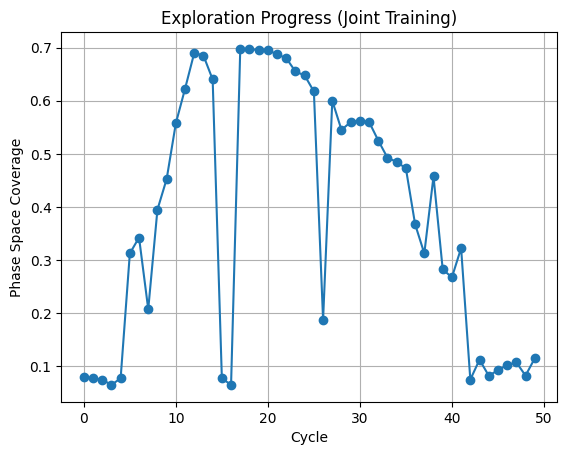

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random

# # === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 64
# LR_DYN = 1e-3
# LR_U = 5e-4
# BETA = 1.0  # Increased Beta to sharpen the policy
# BUFFER_SIZE = 50000
# BATCH_SIZE = 128
# N_CYCLES = 60          # Total "Generations" of the agent
# STEPS_PER_CYCLE = 2000 # Data collection steps per cycle
# DYN_EPOCHS = 1        # Dynamics training epochs per cycle
# U_EPOCHS = 50         # U-learning epochs per cycle
# N_BINS = 20            # For evaluation metrics

ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 128        # Increased capacity for sharp value transitions
LR_DYN = 1e-3
LR_U = 5e-4             # Keep this lower to be stable
BETA = 2.0              # Final target beta

# Annealing schedule for Beta: Start sloppy (0.5), end sharp (2.0)
# (Implement this logic inside your loop: beta = min(2.0, 0.5 + cycle * 0.05))

BUFFER_SIZE = 15000
BATCH_SIZE = 256        # Larger batch = more stable gradients for the eigenvector
N_CYCLES = 50           
STEPS_PER_CYCLE = 2000  

# === CRITICAL CHANGES ===
DYN_EPOCHS = 300        # Train on ~12,800 samples (Replay Ratio ~6)
U_EPOCHS = 1500          # Give the eigenvector solver time to converge
N_BINS = 20


# === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 128
# LR_DYN = 1e-3
# LR_U = 1e-4             # Lower LR for stability
# BETA = 2.0
# BUFFER_SIZE = 100000    # Larger buffer to prevent forgetting "bottom" physics
# BATCH_SIZE = 256
# N_CYCLES = 50
# STEPS_PER_CYCLE = 2000
# DYN_EPOCHS = 50         # Sufficient updates without overfitting
# U_EPOCHS = 200
# POLYAK = 0.05           # Soft update factor


# === 1. Models (Same as before) ===
class ResidualDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, state_dim) 
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

class UNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, action_dim) 
        )
    def forward(self, state):
        return self.net(state)

# === 2. Replay Buffer ===
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, next_state):
        self.buffer.append((state, action, next_state))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, ns = zip(*batch)
        return np.array(s), np.array(a), np.array(ns)
    
    def __len__(self):
        return len(self.buffer)

# === 3. The Joint Trainer ===
class EVE_Joint_Trainer:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        
        # Models
        self.fwd = ResidualDynamicsModel(state_dim, 1)
        self.bwd = ResidualDynamicsModel(state_dim, 1)
        self.logu_net = UNet(state_dim, action_dim)
        self.target_logu = UNet(state_dim, action_dim)
        self.target_logu.load_state_dict(self.logu_net.state_dict())
        
        # Optimizers
        self.opt_f = optim.Adam(self.fwd.parameters(), lr=LR_DYN)
        self.opt_b = optim.Adam(self.bwd.parameters(), lr=LR_DYN)
        self.opt_u = optim.Adam(self.logu_net.parameters(), lr=LR_U)
        
        # Data
        self.buffer = ReplayBuffer(BUFFER_SIZE)
        
        # Normalization Stats (Will update dynamically)
        self.stats = {
            's_mean': torch.zeros(state_dim), 's_std': torch.ones(state_dim),
            'd_mean': torch.zeros(state_dim), 'd_std': torch.ones(state_dim),
            'db_mean': torch.zeros(state_dim), 'db_std': torch.ones(state_dim)
        }

    def update_stats(self):
        # Re-calculate normalization statistics from buffer
        if len(self.buffer) < 100: return
        
        # Sample a large batch to estimate stats
        s, a, ns = self.buffer.sample(len(self.buffer))
        
        s = torch.FloatTensor(s)
        ns = torch.FloatTensor(ns)
        d_fwd = ns - s
        d_bwd = s - ns
        
        self.stats['s_mean'] = s.mean(dim=0)
        self.stats['s_std'] = s.std(dim=0) + 1e-6
        self.stats['d_mean'] = d_fwd.mean(dim=0)
        self.stats['d_std'] = d_fwd.std(dim=0) + 1e-6
        self.stats['db_mean'] = d_bwd.mean(dim=0)
        self.stats['db_std'] = d_bwd.std(dim=0) + 1e-6

    def train_dynamics(self):
        if len(self.buffer) < BATCH_SIZE: return
        criterion = nn.MSELoss()
        
        for _ in range(DYN_EPOCHS):
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize
            s = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            a = torch.FloatTensor(a_np)
            
            # Targets (Normalized Deltas)
            d_fwd_target = ((torch.FloatTensor(ns_np) - torch.FloatTensor(s_np)) - self.stats['d_mean']) / self.stats['d_std']
            d_bwd_target = ((torch.FloatTensor(s_np) - torch.FloatTensor(ns_np)) - self.stats['db_mean']) / self.stats['db_std']
            
            # Update Forward
            pred_d_f = self.fwd(s, a)
            loss_f = criterion(pred_d_f, d_fwd_target)
            self.opt_f.zero_grad(); loss_f.backward(); self.opt_f.step()
            
            # Update Backward (Input is Next State)
            pred_d_b = self.bwd(ns, a)
            loss_b = criterion(pred_d_b, d_bwd_target)
            self.opt_b.zero_grad(); loss_b.backward(); self.opt_b.step()

    def train_u(self):
        if len(self.buffer) < BATCH_SIZE: return
        
        mse = nn.MSELoss()
        
        for _ in range(U_EPOCHS):
            # 1. Sample REAL transitions from Buffer
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize inputs
            s_norm = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns_norm = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            
            # Action indices for the update (the 'a' in u(s,a))
            a_indices = torch.LongTensor(a_np).unsqueeze(1) # [Batch, 1]

            # --- A. Numerator: Real Next State ---
            # E_{a'~pi0} [ u(s', a') ]
            # We use the REAL s' from the buffer.
            with torch.no_grad():
                logu_next_all = self.target_logu(ns_norm) # [Batch, Actions]
                
                # u = exp(beta * Q)
                # Expectation over uniform prior = Mean(u)
                # log(Mean(u)) = log(Sum(u) / N) = LogSumExp(beta*Q) - log(N)
                
                lse_next = torch.logsumexp(logu_next_all, dim=1, keepdim=True)
                log_numerator = lse_next - np.log(self.action_dim)
                
                # Note: log_numerator is log( E[u] )

            # --- B. Denominator: Backward Model Sum ---
            # Sum_{s_bar, a_bar} [ u(s_bar, a_bar)^-1 ]
            valid_log_inv_u_terms = []
            CONSISTENCY_THRESHOLD = 1e-4
            for a_prev_idx in range(self.action_dim):
                a_prev_tensor = torch.full((BATCH_SIZE, 1), float(a_prev_idx))
                
                with torch.no_grad():
                    # 1. Hypothesize Predecessor
                    d_b_pred = self.bwd(s_norm, a_prev_tensor)
                    
                    # Reconstruction logic (Norm -> Unscale -> Add -> Rescale)
                    d_b_real = d_b_pred * self.stats['db_std'] + self.stats['db_mean']
                    s_real = s_norm * self.stats['s_std'] + self.stats['s_mean']
                    prev_real = s_real + d_b_real
                    
                    # Clamp to physics bounds (Implicit "Wall" logic)
                    prev_real[:, 0] = torch.clamp(prev_real[:, 0], -1.2, 0.6)
                    prev_real[:, 1] = torch.clamp(prev_real[:, 1], -0.07, 0.07)
                    
                    prev_norm = (prev_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # 2. VERIFY: Does this prev_state actually lead to s?
                    # s_reconstructed = Forward(prev_norm, a_prev)
                    d_f_check = self.fwd(prev_norm, a_prev_tensor)
                    
                    d_f_check_real = d_f_check * self.stats['d_std'] + self.stats['d_mean']
                    s_check_real = prev_real + d_f_check_real
                    s_check_norm = (s_check_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # Calculate Error ||s_check - s||^2
                    # Sum over state dims (pos, vel)
                    recon_error = torch.sum((s_check_norm - s_norm)**2, dim=1, keepdim=True)
                    
                    # Create Mask: 1 if valid, 0 if invalid
                    is_valid = (recon_error < CONSISTENCY_THRESHOLD).float()
                    
                    # 3. Evaluate u(s_bar, a_bar)
                    q_prev_all = self.target_logu(prev_norm)
                    q_prev = q_prev_all[:, a_prev_idx:a_prev_idx+1]
                    
                    # 4. Term = u^-1 = exp(-beta * Q)
                    # We handle the masking in Log-Space
                    # log(Valid * Term) = log(Valid) + log(Term)
                    # If Valid=0, log(Valid)=-inf. This effectively removes it from LogSumExp.
                    
                    # Safety for log(0): use a large negative number for invalid terms
                    mask_log = torch.log(is_valid + 1e-12) # Will be approx 0 or -27 (small enough)
                    # Better: Set invalid terms directly to -1e9
                    term_log = - q_prev
                    
                    # Apply Mask: If invalid, value becomes -LargeNumber (effectively 0 contribution)
                    masked_term = term_log + (1.0 - is_valid) * -1e9
                    
                    valid_log_inv_u_terms.append(masked_term)
            
            # LogSumExp over only the VALID predecessors
            stack_terms = torch.cat(valid_log_inv_u_terms, dim=1)
            log_denominator = torch.logsumexp(stack_terms, dim=1, keepdim=True)

            # --- C. Target & Update (Unchanged) ---
            # Target Q = (0.5/beta) * (log_num - log_denom)
            target_q_val = 0.5 * (log_numerator - log_denominator)
            target_q_val = target_q_val - target_q_val.mean()
            
            current_q_all = self.logu_net(s_norm)
            current_q_val = current_q_all.gather(1, a_indices.squeeze(1))
            # === FIX 1: The Anchor ===
            # We must force Q(start_state) to be fixed (e.g. 0).
            # Otherwise the whole system drifts.
            # MountainCar start: pos ~ -0.5, vel = 0
            # Normalized start state:
            start_real = torch.tensor([[-0.5, 0.0]])
            start_norm = (start_real - self.stats['s_mean']) / self.stats['s_std']
            
            # Calculate Anchor Loss
            # We want Q(start, :) approx 0
            q_start = self.logu_net(start_norm) # [1, 3]
            anchor_loss = 0.1 * torch.mean(q_start**2) # L2 penalty towards 0

            loss = mse(current_q_val, target_q_val) #+ anchor_loss
            self.opt_u.zero_grad(); loss.backward(); self.opt_u.step()
            # Polyak averaging for target network
            polyak_tau = 0.99
            for param, target_param in zip(self.logu_net.parameters(), self.target_logu.parameters()):
                target_param.data.copy_(polyak_tau * target_param.data + (1 - polyak_tau) * param.data)

        # log the average u value:
        avg_u = current_q_val.mean().item()
        print(f"Average U value: {avg_u:.4f}")


    def get_action(self, state, epsilon=0.1):
        # State is numpy (2,)
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_dim)
        
        # Policy from U
        s_norm = (torch.FloatTensor(state) - self.stats['s_mean']) / self.stats['s_std']
        with torch.no_grad():
            q = self.logu_net(s_norm.unsqueeze(0))
            probs = torch.softmax(BETA * q, dim=1).numpy()[0]
        return np.random.choice(self.action_dim, p=probs)

# === 4. Evaluation Helper ===
def evaluate_coverage(agent, n_episodes=10):
    env = gym.make(ENV_NAME, max_episode_steps=500)
    grid = np.zeros((N_BINS, N_BINS))
    
    for _ in range(n_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            # Use Greedy policy for eval
            a = agent.get_action(s, epsilon=0.0)
            
            # Binning
            pos = int((s[0] + 1.2) / 1.8 * N_BINS); pos = np.clip(pos, 0, N_BINS-1)
            vel = int((s[1] + 0.07) / 0.14 * N_BINS); vel = np.clip(vel, 0, N_BINS-1)
            grid[pos, vel] = 1
            
            s, _, term, trunc, _ = env.step(a)
            done = term or trunc
            
    coverage = np.sum(grid) / (N_BINS * N_BINS)
    return coverage

env = gym.make(ENV_NAME)
trainer = EVE_Joint_Trainer(2, 3)

# Metrics
cov_history = []

print("--- Starting Joint Training ---")

for cycle in range(N_CYCLES):
    # 1. Collect Data (Mixture Policy)
    # Decay epsilon: Start high (0.5) -> End low (0.1)
    eps = max(0.1, 0.5 - cycle * (0.4 / N_CYCLES))
    
    s, _ = env.reset()
    for _ in range(STEPS_PER_CYCLE):
        a = trainer.get_action(s, epsilon=eps)
        ns, _, term, trunc, _ = env.step(a)
        trainer.buffer.push(s, [float(a)], ns)
        
        if term or trunc: s, _ = env.reset()
        else: s = ns
        
    print(f"Cycle {cycle+1}/{N_CYCLES}: Data Collected (Eps={eps:.2f})")
    
    # 2. Update Stats & Train Dynamics
    trainer.update_stats()
    trainer.train_dynamics()
    
    # 3. Train U
    trainer.train_u()
    
    # 4. Evaluate
    cov = evaluate_coverage(trainer)
    cov_history.append(cov)
    print(f"  -> Coverage: {cov:.2%}")

# Plot
plt.plot(cov_history, marker='o')
plt.title("Exploration Progress (Joint Training)")
plt.xlabel("Cycle")
plt.ylabel("Phase Space Coverage")
plt.grid(True)
plt.savefig('joint_training_progress.png')
plt.show()

--- Starting Joint Training ---
Cycle 1/50: Data Collected (Eps=0.50)
Average U value: -0.0042
  -> Coverage: 25.25%
Cycle 2/50: Data Collected (Eps=0.49)
Average U value: 0.0026
  -> Coverage: 21.00%
Cycle 3/50: Data Collected (Eps=0.48)
Average U value: 0.0058
  -> Coverage: 16.50%
Cycle 4/50: Data Collected (Eps=0.48)
Average U value: 0.0019
  -> Coverage: 19.75%
Cycle 5/50: Data Collected (Eps=0.47)
Average U value: -0.0034
  -> Coverage: 18.75%
Cycle 6/50: Data Collected (Eps=0.46)
Average U value: -0.0014
  -> Coverage: 41.75%
Cycle 7/50: Data Collected (Eps=0.45)
Average U value: 0.0005
  -> Coverage: 19.50%
Cycle 8/50: Data Collected (Eps=0.44)
Average U value: -0.0011
  -> Coverage: 20.25%
Cycle 9/50: Data Collected (Eps=0.44)
Average U value: -0.0008
  -> Coverage: 19.50%
Cycle 10/50: Data Collected (Eps=0.43)
Average U value: 0.0004
  -> Coverage: 15.75%
Cycle 11/50: Data Collected (Eps=0.42)
Average U value: 0.0004
  -> Coverage: 20.25%
Cycle 12/50: Data Collected (Eps=0.41

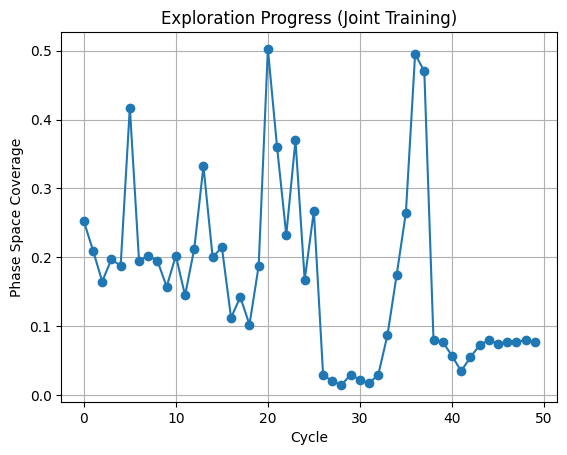

In [72]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random

# # === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 64
# LR_DYN = 1e-3
# LR_U = 5e-4
# BETA = 1.0  # Increased Beta to sharpen the policy
# BUFFER_SIZE = 50000
# BATCH_SIZE = 128
# N_CYCLES = 60          # Total "Generations" of the agent
# STEPS_PER_CYCLE = 2000 # Data collection steps per cycle
# DYN_EPOCHS = 1        # Dynamics training epochs per cycle
# U_EPOCHS = 50         # U-learning epochs per cycle
# N_BINS = 20            # For evaluation metrics

ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 128        # Increased capacity for sharp value transitions
LR_DYN = 1e-3
LR_U = 5e-4             # Keep this lower to be stable
BETA = 1.0              # Final target beta

# Annealing schedule for Beta: Start sloppy (0.5), end sharp (2.0)
# (Implement this logic inside your loop: beta = min(2.0, 0.5 + cycle * 0.05))

BUFFER_SIZE = 4000
BATCH_SIZE = 256        # Larger batch = more stable gradients for the eigenvector
N_CYCLES = 50           
STEPS_PER_CYCLE = 2000  

# === CRITICAL CHANGES ===
DYN_EPOCHS = 300        # Train on ~12,800 samples (Replay Ratio ~6)
U_EPOCHS = 1500          # Give the eigenvector solver time to converge
N_BINS = 20


# === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 128
# LR_DYN = 1e-3
# LR_U = 1e-4             # Lower LR for stability
# BETA = 2.0
# BUFFER_SIZE = 100000    # Larger buffer to prevent forgetting "bottom" physics
# BATCH_SIZE = 256
# N_CYCLES = 50
# STEPS_PER_CYCLE = 2000
# DYN_EPOCHS = 50         # Sufficient updates without overfitting
# U_EPOCHS = 200
# POLYAK = 0.05           # Soft update factor


# === 1. Models (Same as before) ===
class ResidualDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, state_dim) 
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

class UNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, action_dim) 
        )
    def forward(self, state):
        return self.net(state)

# === 2. Replay Buffer ===
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, next_state):
        self.buffer.append((state, action, next_state))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, ns = zip(*batch)
        return np.array(s), np.array(a), np.array(ns)
    
    def __len__(self):
        return len(self.buffer)

# === 3. The Joint Trainer ===
class EVE_Joint_Trainer:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        
        # Models
        self.fwd = ResidualDynamicsModel(state_dim, 1)
        self.bwd = ResidualDynamicsModel(state_dim, 1)
        self.logu_net = UNet(state_dim, action_dim)
        self.target_logu = UNet(state_dim, action_dim)
        self.target_logu.load_state_dict(self.logu_net.state_dict())
        
        # Optimizers
        self.opt_f = optim.Adam(self.fwd.parameters(), lr=LR_DYN)
        self.opt_b = optim.Adam(self.bwd.parameters(), lr=LR_DYN)
        self.opt_u = optim.Adam(self.logu_net.parameters(), lr=LR_U)
        
        # Data
        self.buffer = ReplayBuffer(BUFFER_SIZE)
        
        # Normalization Stats (Will update dynamically)
        self.stats = {
            's_mean': torch.zeros(state_dim), 's_std': torch.ones(state_dim),
            'd_mean': torch.zeros(state_dim), 'd_std': torch.ones(state_dim),
            'db_mean': torch.zeros(state_dim), 'db_std': torch.ones(state_dim)
        }

        self.current_cycle = 0

    def update_stats(self):
        # Re-calculate normalization statistics from buffer
        if len(self.buffer) < 100: return
        
        # Sample a large batch to estimate stats
        s, a, ns = self.buffer.sample(len(self.buffer))
        
        s = torch.FloatTensor(s)
        ns = torch.FloatTensor(ns)
        d_fwd = ns - s
        d_bwd = s - ns
        
        self.stats['s_mean'] = s.mean(dim=0)
        self.stats['s_std'] = s.std(dim=0) + 1e-6
        self.stats['d_mean'] = d_fwd.mean(dim=0)
        self.stats['d_std'] = d_fwd.std(dim=0) + 1e-6
        self.stats['db_mean'] = d_bwd.mean(dim=0)
        self.stats['db_std'] = d_bwd.std(dim=0) + 1e-6

    def train_dynamics(self):
        if len(self.buffer) < BATCH_SIZE: return
        criterion = nn.MSELoss()
        
        for _ in range(DYN_EPOCHS):
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize
            s = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            a = torch.FloatTensor(a_np)
            
            # Targets (Normalized Deltas)
            d_fwd_target = ((torch.FloatTensor(ns_np) - torch.FloatTensor(s_np)) - self.stats['d_mean']) / self.stats['d_std']
            d_bwd_target = ((torch.FloatTensor(s_np) - torch.FloatTensor(ns_np)) - self.stats['db_mean']) / self.stats['db_std']
            
            # Update Forward
            pred_d_f = self.fwd(s, a)
            loss_f = criterion(pred_d_f, d_fwd_target)
            self.opt_f.zero_grad(); loss_f.backward(); self.opt_f.step()
            
            # Update Backward (Input is Next State)
            pred_d_b = self.bwd(ns, a)
            loss_b = criterion(pred_d_b, d_bwd_target)
            self.opt_b.zero_grad(); loss_b.backward(); self.opt_b.step()

    def train_u(self):
        self.current_cycle += 1
        if len(self.buffer) < BATCH_SIZE: return
        
        mse = nn.MSELoss()
        
        for _ in range(U_EPOCHS):
            # 1. Sample REAL transitions from Buffer
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize inputs
            s_norm = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns_norm = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            
            # Action indices for the update (the 'a' in u(s,a))
            a_indices = torch.LongTensor(a_np).unsqueeze(1) # [Batch, 1]

            # --- A. Numerator: Real Next State ---
            # E_{a'~pi0} [ u(s', a') ]
            # We use the REAL s' from the buffer.
            with torch.no_grad():
                logu_next_all = self.target_logu(ns_norm) # [Batch, Actions]
                
                # u = exp(beta * Q)
                # Expectation over uniform prior = Mean(u)
                # log(Mean(u)) = log(Sum(u) / N) = LogSumExp(beta*Q) - log(N)
                
                lse_next = torch.logsumexp(logu_next_all, dim=1, keepdim=True)
                log_numerator = lse_next - np.log(self.action_dim)
                
                # Note: log_numerator is log( E[u] )

            # --- B. Denominator: Backward Model Sum ---
            # Sum_{s_bar, a_bar} [ u(s_bar, a_bar)^-1 ]
            valid_log_inv_u_terms = []
            # Linearly decay log(CONSISTENCY_THRESHOLD) from log(1e-3) to log(1e-8) over N_CYCLES
            log_start = np.log(1e-3)
            log_end = np.log(1e-8)
            frac = self.current_cycle / max(1, N_CYCLES - 1)
            log_thresh = log_start * (1 - frac) + log_end * frac
            CONSISTENCY_THRESHOLD = np.exp(log_thresh)
            for a_prev_idx in range(self.action_dim):
                a_prev_tensor = torch.full((BATCH_SIZE, 1), float(a_prev_idx))
                
                with torch.no_grad():
                    # 1. Hypothesize Predecessor
                    d_b_pred = self.bwd(s_norm, a_prev_tensor)
                    
                    # Reconstruction logic (Norm -> Unscale -> Add -> Rescale)
                    d_b_real = d_b_pred * self.stats['db_std'] + self.stats['db_mean']
                    s_real = s_norm * self.stats['s_std'] + self.stats['s_mean']
                    prev_real = s_real + d_b_real
                    
                    # Clamp to physics bounds (Implicit "Wall" logic)
                    prev_real[:, 0] = torch.clamp(prev_real[:, 0], -1.2, 0.6)
                    prev_real[:, 1] = torch.clamp(prev_real[:, 1], -0.07, 0.07)
                    
                    prev_norm = (prev_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # 2. VERIFY: Does this prev_state actually lead to s?
                    # s_reconstructed = Forward(prev_norm, a_prev)
                    d_f_check = self.fwd(prev_norm, a_prev_tensor)
                    
                    d_f_check_real = d_f_check * self.stats['d_std'] + self.stats['d_mean']
                    s_check_real = prev_real + d_f_check_real
                    s_check_norm = (s_check_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # Calculate Error ||s_check - s||^2
                    # Sum over state dims (pos, vel)
                    recon_error = torch.sum((s_check_norm - s_norm)**2, dim=1, keepdim=True)
                    
                    # Create Mask: 1 if valid, 0 if invalid
                    is_valid = (recon_error < CONSISTENCY_THRESHOLD).float()
                    
                    # 3. Evaluate u(s_bar, a_bar)
                    q_prev_all = self.target_logu(prev_norm)
                    q_prev = q_prev_all[:, a_prev_idx:a_prev_idx+1]
                    
                    # 4. Term = u^-1 = exp(-beta * Q)
                    # We handle the masking in Log-Space
                    # log(Valid * Term) = log(Valid) + log(Term)
                    # If Valid=0, log(Valid)=-inf. This effectively removes it from LogSumExp.
                    
                    # Safety for log(0): use a large negative number for invalid terms
                    mask_log = torch.log(is_valid + 1e-12) # Will be approx 0 or -27 (small enough)
                    # Better: Set invalid terms directly to -1e9
                    term_log = - q_prev
                    
                    # Apply Mask: If invalid, value becomes -LargeNumber (effectively 0 contribution)
                    masked_term = term_log + (1.0 - is_valid) * -1e9
                    
                    valid_log_inv_u_terms.append(masked_term)
            
            # LogSumExp over only the VALID predecessors
            stack_terms = torch.cat(valid_log_inv_u_terms, dim=1)
            log_denominator = torch.logsumexp(stack_terms, dim=1, keepdim=True)

            # --- C. Target & Update (Unchanged) ---
            # Target Q = (0.5/beta) * (log_num - log_denom)
            target_q_val = 0.5 * (log_numerator - log_denominator)
            target_q_val = target_q_val - target_q_val.mean()
            
            current_q_all = self.logu_net(s_norm)
            current_q_val = current_q_all.gather(1, a_indices.squeeze(1))
            # === FIX 1: The Anchor ===
            # We must force Q(start_state) to be fixed (e.g. 0).
            # Otherwise the whole system drifts.
            # MountainCar start: pos ~ -0.5, vel = 0
            # Normalized start state:
            start_real = torch.tensor([[-0.5, 0.0]])
            start_norm = (start_real - self.stats['s_mean']) / self.stats['s_std']
            
            # Calculate Anchor Loss
            # We want Q(start, :) approx 0
            q_start = self.logu_net(start_norm) # [1, 3]
            anchor_loss = 0.1 * torch.mean(q_start**2) # L2 penalty towards 0

            loss = mse(current_q_val, target_q_val) #+ anchor_loss
            self.opt_u.zero_grad(); loss.backward(); self.opt_u.step()
            # Polyak averaging for target network
            polyak_tau = 0.95
            for param, target_param in zip(self.logu_net.parameters(), self.target_logu.parameters()):
                target_param.data.copy_(polyak_tau * target_param.data + (1 - polyak_tau) * param.data)

        # log the average u value:
        avg_u = current_q_val.mean().item()
        print(f"Average U value: {avg_u:.4f}")


    def get_action(self, state, epsilon=0.1):
        # State is numpy (2,)
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_dim)
        
        # Policy from U
        s_norm = (torch.FloatTensor(state) - self.stats['s_mean']) / self.stats['s_std']
        with torch.no_grad():
            q = self.logu_net(s_norm.unsqueeze(0))
            probs = torch.softmax(BETA * q, dim=1).numpy()[0]
        return np.random.choice(self.action_dim, p=probs)

# === 4. Evaluation Helper ===
def evaluate_coverage(agent, n_episodes=10):
    env = gym.make(ENV_NAME, max_episode_steps=500)
    grid = np.zeros((N_BINS, N_BINS))
    
    for _ in range(n_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            # Use Greedy policy for eval
            a = agent.get_action(s, epsilon=0.0)
            
            # Binning
            pos = int((s[0] + 1.2) / 1.8 * N_BINS); pos = np.clip(pos, 0, N_BINS-1)
            vel = int((s[1] + 0.07) / 0.14 * N_BINS); vel = np.clip(vel, 0, N_BINS-1)
            grid[pos, vel] = 1
            
            s, _, term, trunc, _ = env.step(a)
            done = term or trunc
            
    coverage = np.sum(grid) / (N_BINS * N_BINS)
    return coverage

env = gym.make(ENV_NAME)
trainer = EVE_Joint_Trainer(2, 3)

# Metrics
cov_history = []

print("--- Starting Joint Training ---")

for cycle in range(N_CYCLES):
    # 1. Collect Data (Mixture Policy)
    # Decay epsilon: Start high (0.5) -> End low (0.1)
    eps = max(0.1, 0.5 - cycle * (0.4 / N_CYCLES))
    
    s, _ = env.reset()
    for _ in range(STEPS_PER_CYCLE):
        a = trainer.get_action(s, epsilon=eps)
        ns, _, term, trunc, _ = env.step(a)
        trainer.buffer.push(s, [float(a)], ns)
        
        if term or trunc: s, _ = env.reset()
        else: s = ns
        
    print(f"Cycle {cycle+1}/{N_CYCLES}: Data Collected (Eps={eps:.2f})")
    
    # 2. Update Stats & Train Dynamics
    trainer.update_stats()
    trainer.train_dynamics()
    
    # 3. Train U
    trainer.train_u()
    
    # 4. Evaluate
    cov = evaluate_coverage(trainer)
    cov_history.append(cov)
    print(f"  -> Coverage: {cov:.2%}")

# Plot
plt.plot(cov_history, marker='o')
plt.title("Exploration Progress (Joint Training)")
plt.xlabel("Cycle")
plt.ylabel("Phase Space Coverage")
plt.grid(True)
plt.savefig('joint_training_progress.png')
plt.show()

In [60]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random

# # === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 64
# LR_DYN = 1e-3
# LR_U = 5e-4
# BETA = 1.0  # Increased Beta to sharpen the policy
# BUFFER_SIZE = 50000
# BATCH_SIZE = 128
# N_CYCLES = 60          # Total "Generations" of the agent
# STEPS_PER_CYCLE = 2000 # Data collection steps per cycle
# DYN_EPOCHS = 1        # Dynamics training epochs per cycle
# U_EPOCHS = 50         # U-learning epochs per cycle
# N_BINS = 20            # For evaluation metrics

ENV_NAME = "MountainCar-v0"
HIDDEN_DIM = 128        # Increased capacity for sharp value transitions
LR_DYN = 1e-3
LR_U = 5e-4             # Keep this lower to be stable
BETA = 1.0              # Final target beta

# Annealing schedule for Beta: Start sloppy (0.5), end sharp (2.0)
# (Implement this logic inside your loop: beta = min(2.0, 0.5 + cycle * 0.05))

BUFFER_SIZE = 15000
BATCH_SIZE = 256        # Larger batch = more stable gradients for the eigenvector
N_CYCLES = 50           
STEPS_PER_CYCLE = 2000  

# === CRITICAL CHANGES ===
DYN_EPOCHS = 300        # Train on ~12,800 samples (Replay Ratio ~6)
U_EPOCHS = 1500          # Give the eigenvector solver time to converge
N_BINS = 20


# === Configuration ===
# ENV_NAME = "MountainCar-v0"
# HIDDEN_DIM = 128
# LR_DYN = 1e-3
# LR_U = 1e-4             # Lower LR for stability
# BETA = 2.0
# BUFFER_SIZE = 100000    # Larger buffer to prevent forgetting "bottom" physics
# BATCH_SIZE = 256
# N_CYCLES = 50
# STEPS_PER_CYCLE = 2000
# DYN_EPOCHS = 50         # Sufficient updates without overfitting
# U_EPOCHS = 200
# POLYAK = 0.05           # Soft update factor


# === 1. Models (Same as before) ===
class ResidualDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, state_dim) 
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

# === 1. Stabilized U-Network (LayerNorm) ===
class StabilizedUNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_DIM),
            nn.LayerNorm(HIDDEN_DIM), # <--- Fix 1: Stops hidden activations from exploding
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            # nn.LayerNorm(HIDDEN_DIM), # <--- Fix 1
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, action_dim) 
        )
    def forward(self, state):
        return self.net(state)

# === 2. Replay Buffer ===
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, next_state):
        self.buffer.append((state, action, next_state))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, ns = zip(*batch)
        return np.array(s), np.array(a), np.array(ns)
    
    def __len__(self):
        return len(self.buffer)

# === 3. The Joint Trainer ===
class EVE_Joint_Trainer:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        
        # Models
        self.fwd = ResidualDynamicsModel(state_dim, 1)
        self.bwd = ResidualDynamicsModel(state_dim, 1)
        self.logu_net = StabilizedUNet(state_dim, action_dim)
        self.target_logu = StabilizedUNet(state_dim, action_dim)
        self.target_logu.load_state_dict(self.logu_net.state_dict())
        
        # Optimizers
        self.opt_f = optim.Adam(self.fwd.parameters(), lr=LR_DYN)
        self.opt_b = optim.Adam(self.bwd.parameters(), lr=LR_DYN)
        self.opt_u = optim.Adam(self.logu_net.parameters(), lr=LR_U)
        
        # Data
        self.buffer = ReplayBuffer(BUFFER_SIZE)
        
        # Normalization Stats (Will update dynamically)
        self.stats = {
            's_mean': torch.zeros(state_dim), 's_std': torch.ones(state_dim),
            'd_mean': torch.zeros(state_dim), 'd_std': torch.ones(state_dim),
            'db_mean': torch.zeros(state_dim), 'db_std': torch.ones(state_dim)
        }

    def update_stats(self):
        # Re-calculate normalization statistics from buffer
        if len(self.buffer) < 100: return
        
        # Sample a large batch to estimate stats
        s, a, ns = self.buffer.sample(len(self.buffer))
        
        s = torch.FloatTensor(s)
        ns = torch.FloatTensor(ns)
        d_fwd = ns - s
        d_bwd = s - ns
        
        self.stats['s_mean'] = s.mean(dim=0)
        self.stats['s_std'] = s.std(dim=0) + 1e-6
        self.stats['d_mean'] = d_fwd.mean(dim=0)
        self.stats['d_std'] = d_fwd.std(dim=0) + 1e-6
        self.stats['db_mean'] = d_bwd.mean(dim=0)
        self.stats['db_std'] = d_bwd.std(dim=0) + 1e-6

    def train_dynamics(self):
        if len(self.buffer) < BATCH_SIZE: return
        criterion = nn.MSELoss()
        
        for _ in range(DYN_EPOCHS):
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize
            s = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            a = torch.FloatTensor(a_np)
            
            # Targets (Normalized Deltas)
            d_fwd_target = ((torch.FloatTensor(ns_np) - torch.FloatTensor(s_np)) - self.stats['d_mean']) / self.stats['d_std']
            d_bwd_target = ((torch.FloatTensor(s_np) - torch.FloatTensor(ns_np)) - self.stats['db_mean']) / self.stats['db_std']
            
            # Update Forward
            pred_d_f = self.fwd(s, a)
            loss_f = criterion(pred_d_f, d_fwd_target)
            self.opt_f.zero_grad(); loss_f.backward(); self.opt_f.step()
            
            # Update Backward (Input is Next State)
            pred_d_b = self.bwd(ns, a)
            loss_b = criterion(pred_d_b, d_bwd_target)
            self.opt_b.zero_grad(); loss_b.backward(); self.opt_b.step()

    def train_u(self):
        if len(self.buffer) < BATCH_SIZE: return
        mse = nn.MSELoss()
        
        # Trackers
        grad_norms = []
        policy_entropies = []
        
        for _ in range(U_EPOCHS):
            # 1. Sample REAL transitions from Buffer
            s_np, a_np, ns_np = self.buffer.sample(BATCH_SIZE)
            
            # Normalize inputs
            s_norm = (torch.FloatTensor(s_np) - self.stats['s_mean']) / self.stats['s_std']
            ns_norm = (torch.FloatTensor(ns_np) - self.stats['s_mean']) / self.stats['s_std']
            
            # Action indices for the update (the 'a' in u(s,a))
            a_indices = torch.LongTensor(a_np).unsqueeze(1) # [Batch, 1]

            # --- A. Numerator: Real Next State ---
            # E_{a'~pi0} [ u(s', a') ]
            # We use the REAL s' from the buffer.
            with torch.no_grad():
                logu_next_all = self.target_logu(ns_norm) # [Batch, Actions]
                
                # u = exp(beta * Q)
                # Expectation over uniform prior = Mean(u)
                # log(Mean(u)) = log(Sum(u) / N) = LogSumExp(beta*Q) - log(N)
                
                lse_next = torch.logsumexp(logu_next_all, dim=1, keepdim=True)
                log_numerator = lse_next - np.log(self.action_dim)
                
                # Note: log_numerator is log( E[u] )

            # --- B. Denominator: Backward Model Sum ---
            # Sum_{s_bar, a_bar} [ u(s_bar, a_bar)^-1 ]
            valid_log_inv_u_terms = []
            CONSISTENCY_THRESHOLD = 1e-4
            for a_prev_idx in range(self.action_dim):
                a_prev_tensor = torch.full((BATCH_SIZE, 1), float(a_prev_idx))
                
                with torch.no_grad():
                    # 1. Hypothesize Predecessor
                    d_b_pred = self.bwd(s_norm, a_prev_tensor)
                    
                    # Reconstruction logic (Norm -> Unscale -> Add -> Rescale)
                    d_b_real = d_b_pred * self.stats['db_std'] + self.stats['db_mean']
                    s_real = s_norm * self.stats['s_std'] + self.stats['s_mean']
                    prev_real = s_real + d_b_real
                    
                    # Clamp to physics bounds (Implicit "Wall" logic)
                    prev_real[:, 0] = torch.clamp(prev_real[:, 0], -1.2, 0.6)
                    prev_real[:, 1] = torch.clamp(prev_real[:, 1], -0.07, 0.07)
                    
                    prev_norm = (prev_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # 2. VERIFY: Does this prev_state actually lead to s?
                    # s_reconstructed = Forward(prev_norm, a_prev)
                    d_f_check = self.fwd(prev_norm, a_prev_tensor)
                    
                    d_f_check_real = d_f_check * self.stats['d_std'] + self.stats['d_mean']
                    s_check_real = prev_real + d_f_check_real
                    s_check_norm = (s_check_real - self.stats['s_mean']) / self.stats['s_std']
                    
                    # Calculate Error ||s_check - s||^2
                    # Sum over state dims (pos, vel)
                    recon_error = torch.sum((s_check_norm - s_norm)**2, dim=1, keepdim=True)
                    
                    # Create Mask: 1 if valid, 0 if invalid
                    is_valid = (recon_error < CONSISTENCY_THRESHOLD).float()
                    
                    # 3. Evaluate u(s_bar, a_bar)
                    q_prev_all = self.target_logu(prev_norm)
                    q_prev = q_prev_all[:, a_prev_idx:a_prev_idx+1]
                    
                    # 4. Term = u^-1 = exp(-beta * Q)
                    # We handle the masking in Log-Space
                    # log(Valid * Term) = log(Valid) + log(Term)
                    # If Valid=0, log(Valid)=-inf. This effectively removes it from LogSumExp.
                    
                    # Safety for log(0): use a large negative number for invalid terms
                    mask_log = torch.log(is_valid + 1e-12) # Will be approx 0 or -27 (small enough)
                    # Better: Set invalid terms directly to -1e9
                    term_log = - q_prev
                    
                    # Apply Mask: If invalid, value becomes -LargeNumber (effectively 0 contribution)
                    masked_term = term_log + (1.0 - is_valid) * -1e9
                    
                    valid_log_inv_u_terms.append(masked_term)
            
            # LogSumExp over only the VALID predecessors
            stack_terms = torch.cat(valid_log_inv_u_terms, dim=1)
            log_denominator = torch.logsumexp(stack_terms, dim=1, keepdim=True)

            # --- C. Target & Update (Unchanged) ---
            # Target Q = (0.5/beta) * (log_num - log_denom)
            target_q_val = 0.5 * (log_numerator - log_denominator)
            # target_q_val = target_q_val - target_q_val.mean()
            
            current_q_all = self.logu_net(s_norm)
            current_q_val = current_q_all.gather(1, a_indices.squeeze(1))
            # === FIX 1: The Anchor ===
            # We must force Q(start_state) to be fixed (e.g. 0).
            # Otherwise the whole system drifts.
            # MountainCar start: pos ~ -0.5, vel = 0
            # Normalized start state:
            start_real = torch.tensor([[-0.5, 0.0]])
            start_norm = (start_real - self.stats['s_mean']) / self.stats['s_std']
            
            # Calculate Anchor Loss
            # We want Q(start, :) approx 0
            q_start = self.logu_net(start_norm) # [1, 3]
            anchor_loss = 0.1 * torch.mean(q_start**2) # L2 penalty towards 0

            loss = mse(current_q_val, target_q_val) + anchor_loss
            self.opt_u.zero_grad(); loss.backward(); self.opt_u.step()
            # Polyak averaging for target network
            tau = 0.99
            for p, tp in zip(self.logu_net.parameters(), self.target_logu.parameters()):
                tp.data.copy_(tau * tp.data + (1-tau) * p.data)
                
            # === LOGGING METRICS ===
            # 1. Gradient Norm
            total_norm = 0.0
            for p in self.logu_net.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item()
            grad_norms.append(total_norm)
            
            # 2. Policy Entropy
            with torch.no_grad():
                # q is log-u. Policy is softmax(beta * q)
                # We reuse current_q_all from above
                probs = torch.softmax(BETA * current_q_all, dim=1)
                log_probs = torch.log(probs + 1e-10)
                entropy = -(probs * log_probs).sum(dim=1).mean().item()
                policy_entropies.append(entropy)

        # Print Diagnostics
        print(f"  > Avg U: {current_q_val.mean().item():.2f} (Target 0.0)")
        print(f"  > Grad Norm: {np.mean(grad_norms):.4f}")
        print(f"  > Policy Entropy: {np.mean(policy_entropies):.4f} (Max: {np.log(3):.2f})")
        # log the average u value:
        avg_u = current_q_val.mean().item()
        print(f"Average U value: {avg_u:.4f}")


    def get_action(self, state, epsilon=0.1):
        # State is numpy (2,)
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_dim)
        
        # Policy from U
        s_norm = (torch.FloatTensor(state) - self.stats['s_mean']) / self.stats['s_std']
        with torch.no_grad():
            q = self.logu_net(s_norm.unsqueeze(0))
            probs = torch.softmax(BETA * q, dim=1).numpy()[0]
        return np.random.choice(self.action_dim, p=probs)

# === 4. Evaluation Helper ===
def evaluate_coverage(agent, n_episodes=10):
    env = gym.make(ENV_NAME, max_episode_steps=500)
    grid = np.zeros((N_BINS, N_BINS))
    
    for _ in range(n_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            # Use Greedy policy for eval
            a = agent.get_action(s, epsilon=0.0)
            
            # Binning
            pos = int((s[0] + 1.2) / 1.8 * N_BINS); pos = np.clip(pos, 0, N_BINS-1)
            vel = int((s[1] + 0.07) / 0.14 * N_BINS); vel = np.clip(vel, 0, N_BINS-1)
            grid[pos, vel] = 1
            
            s, _, term, trunc, _ = env.step(a)
            done = term or trunc
            
    coverage = np.sum(grid) / (N_BINS * N_BINS)
    return coverage

env = gym.make(ENV_NAME)
trainer = EVE_Joint_Trainer(2, 3)

# Metrics
cov_history = []

print("--- Starting Joint Training ---")

for cycle in range(N_CYCLES):
    # 1. Collect Data (Mixture Policy)
    # Decay epsilon: Start high (0.5) -> End low (0.1)
    eps = max(0.1, 0.5 - cycle * (0.4 / N_CYCLES))
    
    s, _ = env.reset()
    for _ in range(STEPS_PER_CYCLE):
        a = trainer.get_action(s, epsilon=eps)
        ns, _, term, trunc, _ = env.step(a)
        trainer.buffer.push(s, [float(a)], ns)
        
        if term or trunc: s, _ = env.reset()
        else: s = ns
        
    print(f"Cycle {cycle+1}/{N_CYCLES}: Data Collected (Eps={eps:.2f})")
    
    # 2. Update Stats & Train Dynamics
    trainer.update_stats()
    trainer.train_dynamics()
    
    # 3. Train U
    trainer.train_u()
    
    # 4. Evaluate
    cov = evaluate_coverage(trainer)
    cov_history.append(cov)
    print(f"  -> Coverage: {cov:.2%}")

# Plot
plt.plot(cov_history, marker='o')
plt.title("Exploration Progress (Joint Training)")
plt.xlabel("Cycle")
plt.ylabel("Phase Space Coverage")
plt.grid(True)
plt.savefig('joint_training_progress.png')
plt.show()

--- Starting Joint Training ---
Cycle 1/50: Data Collected (Eps=0.50)
  > Avg U: -8.19 (Target 0.0)
  > Grad Norm: 0.4106
  > Policy Entropy: 1.0978 (Max: 1.10)
Average U value: -8.1864
  -> Coverage: 17.50%
Cycle 2/50: Data Collected (Eps=0.49)
  > Avg U: -16.34 (Target 0.0)
  > Grad Norm: 3.9924
  > Policy Entropy: 1.0961 (Max: 1.10)
Average U value: -16.3406
  -> Coverage: 20.50%
Cycle 3/50: Data Collected (Eps=0.48)
  > Avg U: -24.32 (Target 0.0)
  > Grad Norm: 17.5617
  > Policy Entropy: 1.0871 (Max: 1.10)
Average U value: -24.3187
  -> Coverage: 17.00%
Cycle 4/50: Data Collected (Eps=0.48)
  > Avg U: -32.63 (Target 0.0)
  > Grad Norm: 32.2546
  > Policy Entropy: 1.0863 (Max: 1.10)
Average U value: -32.6305
  -> Coverage: 19.75%
Cycle 5/50: Data Collected (Eps=0.47)
  > Avg U: -40.91 (Target 0.0)
  > Grad Norm: 68.4948
  > Policy Entropy: 1.0882 (Max: 1.10)
Average U value: -40.9090
  -> Coverage: 25.25%
Cycle 6/50: Data Collected (Eps=0.46)
  > Avg U: -49.16 (Target 0.0)
  > Grad

KeyboardInterrupt: 

In [68]:
# get uniform policy coverage for comparison
# === 4. Evaluation Helper ===
def unif_coverage(n_episodes=10):
    env = gym.make(ENV_NAME, max_episode_steps=500)
    grid = np.zeros((N_BINS, N_BINS))
    
    for _ in range(n_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            # Use Uniform policy for eval
            a = np.random.randint(0, 3)  # 3 actions in MountainCar
            
            # Binning
            pos = int((s[0] + 1.2) / 1.8 * N_BINS); pos = np.clip(pos, 0, N_BINS-1)
            vel = int((s[1] + 0.07) / 0.14 * N_BINS); vel = np.clip(vel, 0, N_BINS-1)
            grid[pos, vel] = 1
            
            s, _, term, trunc, _ = env.step(a)
            done = term or trunc
            
    coverage = np.sum(grid) / (N_BINS * N_BINS)
    return coverage
import scipy.stats as st

results = []
for _ in range(50):
    cov = unif_coverage(n_episodes=10)
    results.append(cov)

mean_cov = np.mean(results)
stderr_cov = st.sem(results)
print(f"Uniform Random Policy Coverage over 50 runs: {mean_cov:.2%} ± {stderr_cov:.2%} (stderr)")

Uniform Random Policy Coverage over 50 runs: 19.34% ± 0.65% (stderr)
